# Standard Problem Domainwall Pinning


## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/1tMKEFtOfg7NSCGYUONeHLa0nC0AXVGRP#scrollTo=755d81e8) to try out.

## Install magnum.np and download reference data if not available

In [1]:
!pip install -q magnumnp numpy==1.22.4

In [7]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_dieter.dat
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_magnumaf.dat
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_ref.dat

## Run Demo:

In [ ]:
from magnumnp import *
import numpy as np

Timer.enable()
Hextmax=2.5/constants.mu_0
Hextmin=0.0/constants.mu_0
tfinal = 20e-9

n  = (80, 1, 1)
dx = (1e-9, 1e-9, 1e-9)
origin = (-n[0]*dx[0]/2., -n[1]*dx[1]/2., -n[2]*dx[2]/2.,)
mesh = Mesh(n, dx, origin)
state = State(mesh)
state.material = {"alpha": 1.}
x, y, z = state.SpatialCoordinate()

soft = (x < 0)
hard = (x >= 0)

Ms = state.Constant([0.0]) 
Ms[soft] = 0.25/constants.mu_0
Ms[hard] = 1./constants.mu_0

Ku = state.Constant([0.0]) 
Ku[soft] = 1e5 
Ku[hard] = 1e6 

A = state.Constant([0.0]) 
A[soft] = 0.25e-11
A[hard] = 1.e-11

state.material['Ms'] = Ms
state.material['A'] = A
state.material['Ku'] = Ku
state.material['Ku_axis'] = [0,1,0]

state.m = state.Constant([np.sin(0.3), np.cos(0.3), 0.0]) 
state.m[hard] = state.Tensor([0.0, -1.0, 0.0])
state.m.normalize()

exchange = ExchangeField()
aniso = UniaxialAnisotropyField()

external = ExternalField(lambda t: state.Constant([0, (Hextmax-Hextmin)*t/tfinal+Hextmin, 0]))

llg = LLGSolver([exchange, aniso, external])
logger = ScalarLogger("data/m.dat", ['t', external.h, 'm'])
while state.t < tfinal:
    llg.step(state, 1e-11)
    logger << state

Timer.print_report()


## Plot Results:

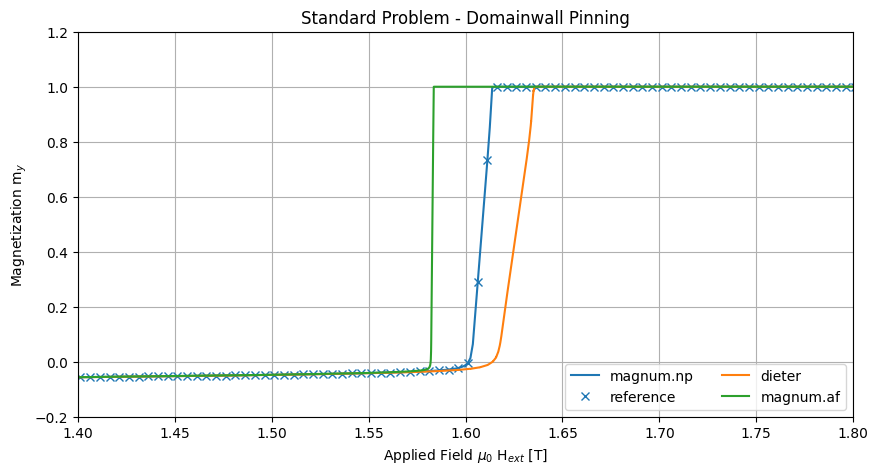

In [2]:
import matplotlib.pyplot as plt

data = np.loadtxt("data/m.dat")
ref = np.loadtxt("ref/m_ref.dat")
data_dieter = np.loadtxt("ref/m_dieter.dat")
data_magnumaf = np.loadtxt("ref/m_magnumaf.dat")


fig, ax = plt.subplots(figsize=(10,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax.plot(data[:,2]*4*np.pi*1e-7, data[:,5], '-', color = cycle[0], label = "magnum.np")
ax.plot(ref[:,2][0::4]*4*np.pi*1e-7, ref[:,5][0::4], 'x', color = cycle[0], linewidth = 6, label = "reference")
ax.plot(data_dieter[:,1], data_dieter[:,3], '-', color = cycle[1], label = "dieter")
ax.plot(data_magnumaf[:,4]*4*np.pi*1e-7, data_magnumaf[:,2], '-', color = cycle[2], label = "magnum.af")

ax.set_xlim([1.4,1.8])
ax.set_ylim([-0.2,1.2])
ax.set_title("Standard Problem - Domainwall Pinning")
ax.set_xlabel("Applied Field $\mu$$_0$ H$_{ext}$ [T]")
ax.set_ylabel("Magnetization m$_y$")
ax.legend(ncol=2, loc='lower right')
ax.grid()
fig.savefig("data/results.png")
